## Learning Objectives

After this lesson, you will be able to:
- Explain the core concepts of Xarray library and differences between the DataArray and Dataset data structures.
- Load, view and explore multidimensional climate datasets (NetCDF format) using Xarray.
- Perform temporal (time-based) and spatial (latitude-longitude) data selections and slicing.
- Calculate and visualize climatological statistics (e.g., means, seasonal averages, and anomalies).
- Construct and interpret meaningful time series visualizations from multidimensional climate data.

This notebook demonstrates how to conduct spatiotemporal analysis using **Xarray**, a powerful Python library designed for multidimensional climate data analysis.

## Introduction to Xarray

### What is Xarray?
- **Xarray** extends the capabilities of NumPy arrays by adding dimension labels and coordinates.
- It simplifies multidimensional data manipulation, especially for climate and geospatial datasets.

### Why use Xarray in climate science?
- Easy handling of labeled multidimensional arrays (e.g., latitude, longitude, time).
- Built-in support for reading and writing NetCDF files.
- Simple integration with visualization libraries (Matplotlib, Cartopy, Seaborn).
- The possibility to select and combine data along a dimension across all arrays in a Dataset simultaneously
- Compatibility with a large ecosystem of Python libraries that work with arrays / raster data

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

## Data Structures

The two fundamental data structures provided by the xarray library are `DataArray` and `Dataset`. Both of them build upon and extend the strengths of numpy and pandas libraries. 
- DataArray is a labeled N-dimensional array that is similar to pandas.Series but works with raster data (stored as numpy arrays). 
- Dataset is a multi-dimensional in-memory array database that contains multiple DataArray objects that share coordinates and attributes.

![Key `xarray` data structures. Image source: Xarray Community (2024), licensed under Apache 2.0.](img/xarray-dataset-diagram.png)

## Loading and Exploring GPCP Data

In the following we will work with the Global Precipitation Climatology Project (GPCP) 2.5-degree monthly dataset in `NETCDF` format. 

### Introduction to NetCDF

NetCDF (Network Common Data Form) is a widely-used, standardized data format developed specifically to store, organize, and share multidimensional scientific data. It was developed by the Unidata Program Center at UCAR (University Corporation for Atmospheric Research) and is particularly popular in the climate, atmospheric, oceanographic, and Earth sciences communities due to its efficiency in managing large datasets and ease of use.

Key Features of NetCDF:
- Self-describing: NetCDF files include metadata (data about data), making it easier for users to understand the contents without external documentation.
- Multidimensional arrays: Supports storing data in multiple dimensions (e.g., time, latitude, longitude, altitude), allowing for effective storage of spatiotemporal data.
- Portable and Platform-independent: NetCDF files can be read, written, and manipulated across various programming languages (e.g., Python, R, MATLAB) and operating systems
- Efficient Data Access: Allows direct, random access to subsets of large datasets without loading the entire dataset into memory.
- Compression support: NetCDF supports data compression, significantly reducing storage requirements for large climate datasets.
- Streamlines workflows for processing and analyzing climate data due to its compatibility with libraries such as Xarray, netCDF4, and CDO/NCO.

In Python, we will need to install the `netCDF4` package to work with NETCDF format.

After activating your `pythongis` environment, type: `conda install netcdf4`

In [2]:
gpcp = xr.open_dataset('data/precip.mon.mean.nc')
gpcp

<xarray.Dataset> Size: 23MB
Dimensions:    (time: 554, nv: 2, lat: 72, lon: 144)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2025-02-01
  * lat        (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon        (lon) float32 576B 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 9kB ...
    lat_bnds   (lat, nv) float32 576B ...
    lon_bnds   (lon, nv) float32 1kB ...
    precip     (time, lat, lon) float32 23MB ...
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2025/01 through latest.

The Dataset has four dimensions: lat, lon, time, and nv. We are interested in the `precip` DataArray, which has three dimensions (time, lat, lon), each with a range of values given by the coordinate variables of the same name (time, lat, lon). Let's check the precip DataArray:

In [3]:
gpcp.precip

<xarray.DataArray 'precip' (time: 554, lat: 72, lon: 144)> Size: 23MB
[5743872 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2025-02-01
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

## Data Selection and Indexing
Xarray simplifies both spatial and temporal data extraction using labeled dimensions.

### Spatial selection
Xarray allows intuitive spatial selection using .sel() and .isel():
- .sel() selects data by coordinate values.
- .isel() selects data by integer indices.

**Important note**: When using .sel(), slicing is inclusive for coordinate labels. Also, latitude usually decreases from top (north) to bottom (south). If your latitude axis is reversed, adjust slices accordingly, e.g., lat=slice(50,20).

In [4]:
# Spatial selection by integer indexing:
grid_point = gpcp['precip'].isel(lat=10, lon=15)
grid_point

<xarray.DataArray 'precip' (time: 554)> Size: 2kB
[554 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2025-02-01
    lat      float32 4B -63.75
    lon      float32 4B 38.75
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

In [5]:
# Selecting data at a single grid point:
point = gpcp['precip'].sel(lat=1.25, lon=181.25)
point


<xarray.DataArray 'precip' (time: 554)> Size: 2kB
[554 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2025-02-01
    lat      float32 4B 1.25
    lon      float32 4B 181.2
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

In [6]:
# Selecting data for a spatial region (bounding box):
region = gpcp['precip'].sel(lat=slice(20, 50), lon=slice(100, 130))
region

<xarray.DataArray 'precip' (time: 554, lat: 12, lon: 12)> Size: 319kB
[79776 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2025-02-01
  * lat      (lat) float32 48B 21.25 23.75 26.25 28.75 ... 43.75 46.25 48.75
  * lon      (lon) float32 48B 101.2 103.8 106.2 108.8 ... 123.8 126.2 128.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

### Temporal indexing
Temporal selection works exactly the same way, but leverages datetime coordinates.

In [7]:
# Selecting using integer indexing for time steps:
first_month = gpcp['precip'].isel(time=0)
first_month

<xarray.DataArray 'precip' (lat: 72, lon: 144)> Size: 41kB
[10368 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    time     datetime64[ns] 8B 1979-01-01
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

In [8]:
# Extract precipitation data for a specific date
single_date = gpcp['precip'].sel(time='2010-06-01')
single_date

<xarray.DataArray 'precip' (lat: 72, lon: 144)> Size: 41kB
[10368 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    time     datetime64[ns] 8B 2010-06-01
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

In [9]:
# Extract data between two dates (inclusive)
period = gpcp['precip'].sel(time=slice('2000-01-01', '2010-12-31'))
period

<xarray.DataArray 'precip' (time: 132, lat: 72, lon: 144)> Size: 5MB
[1368576 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2010-12-01
  * lat      (lat) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

### Combined Spatial and Temporal Selection
Xarray easily supports selecting subsets combining both spatial and temporal dimensions:

In [10]:
subset = gpcp['precip'].sel(
    time=slice('2000-01-01', '2010-12-31'), 
    lat=slice(20, 50), 
    lon=slice(100, 130)
)
subset

<xarray.DataArray 'precip' (time: 132, lat: 12, lon: 12)> Size: 76kB
[19008 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2010-12-01
  * lat      (lat) float32 48B 21.25 23.75 26.25 28.75 ... 43.75 46.25 48.75
  * lon      (lon) float32 48B 101.2 103.8 106.2 108.8 ... 123.8 126.2 128.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

### Advanced Selection Methods

Xarray supports interpolation or selecting nearest neighbors when exact coordinate matches don't exist:

**Nearest neighbor selection** (very useful for irregular grids):

In [11]:
nearest_point = gpcp['precip'].sel(lat=0, lon=0, method='nearest')
nearest_point

<xarray.DataArray 'precip' (time: 554)> Size: 2kB
[554 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2025-02-01
    lat      float32 4B 1.25
    lon      float32 4B 1.25
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

Using **.where()** for Conditional Selection

In [12]:
heavy_precip = gpcp['precip'].where(gpcp['precip'] > 10)
print('minimum precip:', heavy_precip.min().item())
print('maximum precip:', heavy_precip.max().item())

minimum precip: 10.000085830688477
maximum precip: 47.32743453979492


## Statistical Aggregations

In this section we will compute long-term monthly mean climatologies and seasonal cycles.

### Monthly mean climatology
To obtain information about the long-term climatological patterns of the annual cycle, we can calculate the monthly mean climatology by computing the month-wise averages for all years, i.e., for the January, February, ... months of all years.

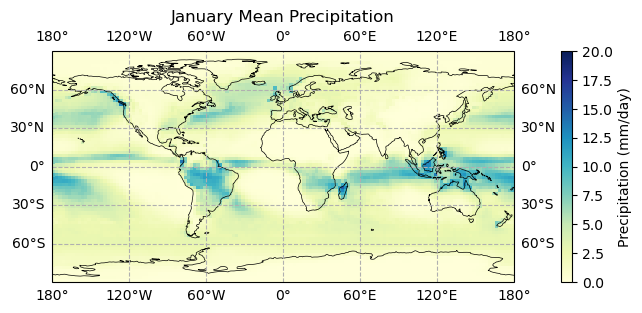

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore")

# Long-term monthly mean climatology
climatology = gpcp.precip.groupby('time.month').mean('time')

# Select January mean precipitation climatology
january_precip = climatology.sel(month=1)

# Plot the climatology using cartopy
fig = plt.figure(figsize=(10,3))
ax = plt.axes(projection=ccrs.PlateCarree())

precip_plot = january_precip.plot(
    ax=ax,
    vmin=0,
    vmax=20,
    cmap='YlGnBu',
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Precipitation (mm/day)', 'pad': 0.06}
)

# Add coastlines and gridlines
ax.coastlines(linewidth=.5)
ax.gridlines(draw_labels=True, linestyle='--')


# Add title
ax.set_title('January Mean Precipitation')

plt.show()

We can use the `climatology` DataArray from above to create a bar plot for the monthly precipitation over North America.

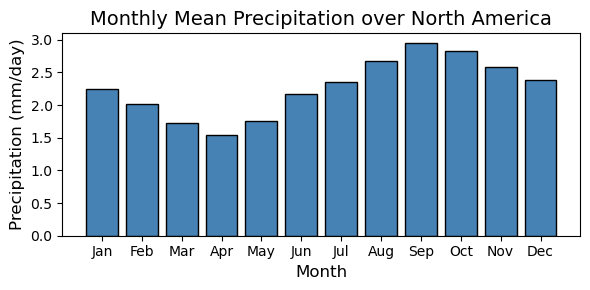

In [14]:
# Spatial selection for North America
na_climatology = climatology.sel(lat=slice(10,75),lon=slice(190,310))

# Average spatially to get regional mean precipitation
na_climatology_mean = na_climatology.mean(dim=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(6, 3))
# Plot bar plot
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.bar(months, na_climatology_mean, color='steelblue', edgecolor='k')

# Add title and labels
ax.set_title('Monthly Mean Precipitation over North America', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Precipitation (mm/day)', fontsize=12)

# Improve layout
plt.tight_layout()
plt.show()


### Seasonal mean climatology.
Similar to the monthly mean climatology, we can calculate the mean precipitation for each season (DJF, MAM, JJA, SON) over a given time period.

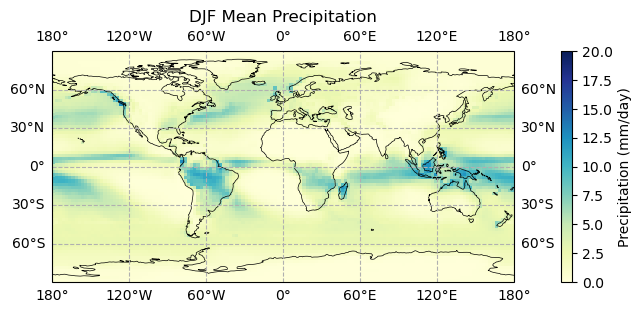

In [15]:
# Seasonal aggregation
# Compute seasonal averages
seasonal_precip = gpcp.precip.groupby('time.season').mean('time')

# Seasonal mean for DJF
djf_precip = seasonal_precip.sel(season='DJF')

# Plot the climatology using cartopy
fig = plt.figure(figsize=(10,3))
ax = plt.axes(projection=ccrs.PlateCarree())

djf_precip.plot(
    ax=ax,
    vmin=0,
    vmax=20,
    cmap='YlGnBu',
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Precipitation (mm/day)', 'pad': 0.06}
)

# Add coastlines and gridlines
ax.coastlines(linewidth=.5)
ax.gridlines(draw_labels=True, linestyle='--')

# Add title
ax.set_title('DJF Mean Precipitation')

plt.show()

## Time-Series Analysis

We often want to analyze precipitation trends over specific regions. Let's use North America as an example. A first step is to slice the DataArray for the regional domain. We will create a regional map to confirm the spatial selection.

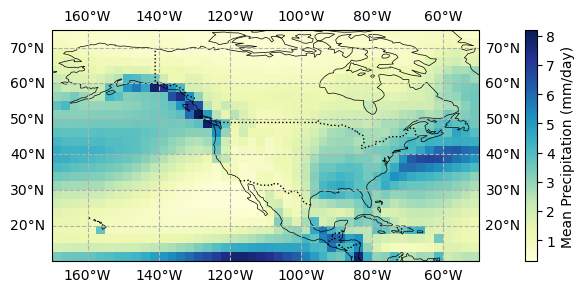

In [16]:
# Regional Average Precipitation Time-Series

# Select the region for North America
na_precip =  gpcp['precip'].sel(lat=slice(10,75),lon=slice(190,310))

# Plot the data to verify the spatial coverage:
fig = plt.figure(figsize=(10,3))
ax = plt.axes(projection=ccrs.PlateCarree())

na_precip.mean(dim='time').plot(
    ax=ax,
    cmap='YlGnBu',
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Mean Precipitation (mm/day)', 'pad': 0.06},
    )

# Add coastlines and borders
ax.coastlines(linewidth=.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Set geographical extent
ax.set_extent([-170, -50, 10, 75], crs=ccrs.PlateCarree())

# Add gridlines
ax.gridlines(draw_labels=True, linestyle='--')

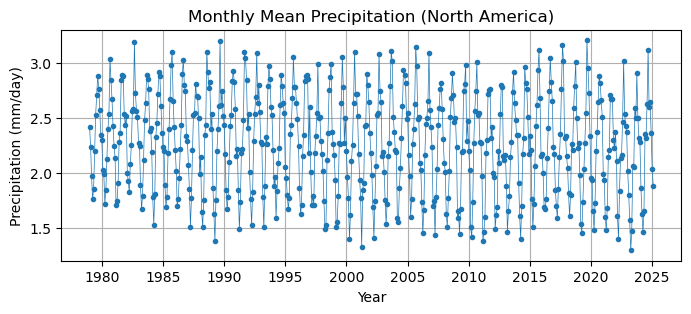

In [17]:
# Compute spatial average (area-averaged precipitation)
na_precip_ts = na_precip.mean(dim=['lat', 'lon'])

#Plot Regional Mean Precipitation Time Series
fig, ax = plt.subplots(figsize=(8, 3))

na_precip_ts.plot(ax=ax, marker='o', markersize=3, linestyle='-', linewidth=0.5)

ax.set_title('Monthly Mean Precipitation (North America)')
ax.set_ylabel('Precipitation (mm/day)')
ax.set_xlabel('Year')

plt.grid()
plt.show()

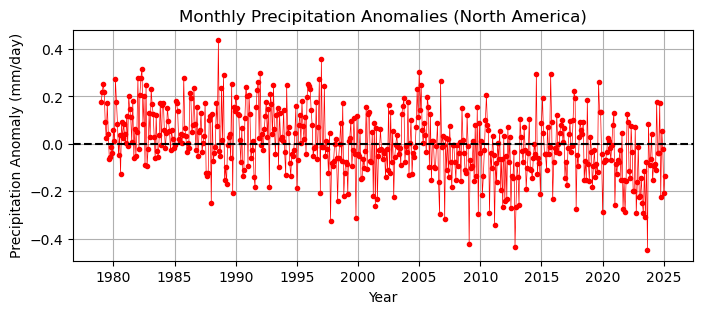

In [18]:
# Calculate anomalies by subtracting climatology

# Calculate the monthly climatology (monthly-wise average)
climatology = na_precip.groupby('time.month').mean(dim='time')

# Calculate anomalies by subtracting the climatological mean
na_anomalies = na_precip.groupby('time.month') - climatology
na_anomalies_ts = na_anomalies.mean(dim=['lat', 'lon'])

# Plot anomaly time series
fig, ax = plt.subplots(figsize=(8,3))

na_anomalies_ts.plot(ax=ax, color='r', marker='o', markersize=3, linewidth=0.5)

ax.axhline(0, color='black', linestyle='--')
ax.set_title('Monthly Precipitation Anomalies (North America)')
ax.set_ylabel('Precipitation Anomaly (mm/day)')
ax.set_xlabel('Year')

plt.grid()
plt.show()

## Hovmöller Diagram (Time–Longitude Plot)

A Hovmöller diagram is a powerful way to visualize the evolution of atmospheric variables over time and across a single spatial dimension (longitude or latitude). Typically, it shows how meteorological features propagate through space and time.

Here, we'll create a Hovmöller diagram of monthly precipitation over 30N-60N, illustrating variations across longitude. To generate a longitude-time Hovmöller diagram, we average precipitation over a chosen latitude band:

In [19]:
# Select a latitude band covering Northern Hemisphere
lat_band_precip = gpcp['precip'].sel(
    lat=slice(30,60),
    time=slice('2001','2020')
).mean(dim='lat')

lat_band_precip

<xarray.DataArray 'precip' (time: 240, lon: 144)> Size: 138kB
array([[2.3625383, 2.5724776, 2.9193535, ..., 4.29334  , 3.7143333,
        2.7328205],
       [2.014371 , 2.1457891, 2.1137307, ..., 2.8197958, 2.567495 ,
        2.4132519],
       [2.4729936, 2.3130527, 3.054641 , ..., 4.0601287, 3.3268292,
        2.6740522],
       ...,
       [2.61983  , 2.7129707, 3.0540788, ..., 4.0346446, 3.7850468,
        3.0501804],
       [1.9858803, 2.0495715, 2.4110663, ..., 3.4476671, 2.4577744,
        1.7062664],
       [3.0616941, 2.812383 , 3.5710678, ..., 4.449433 , 4.147928 ,
        3.5481365]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2001-01-01 2001-02-01 ... 2020-12-01
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    long_name:     Average Monthly Rate of Precipitation
    valid_range:   [  0. 100.]
    units:         mm/day
    precision:     32767
    var_desc:      Precipitation
    dataset:       GPCP Version 2.3 Combined Precipitation Dataset
    level_desc:    Surface
    statistic:     Mean
    parent_stat:   Mean
    actual_range:  [ 0.       47.327435]

For clearer visualization, let's calculate anomalies:

In [20]:
# Calculate climatology by averaging over the entire time period for each month
climatology = lat_band_precip.groupby('time.month').mean('time')

# Calculate anomalies by removing climatology
precip_anomalies = lat_band_precip.groupby('time.month') - climatology


Plot the Hovmöller Diagram (Time–Longitude)

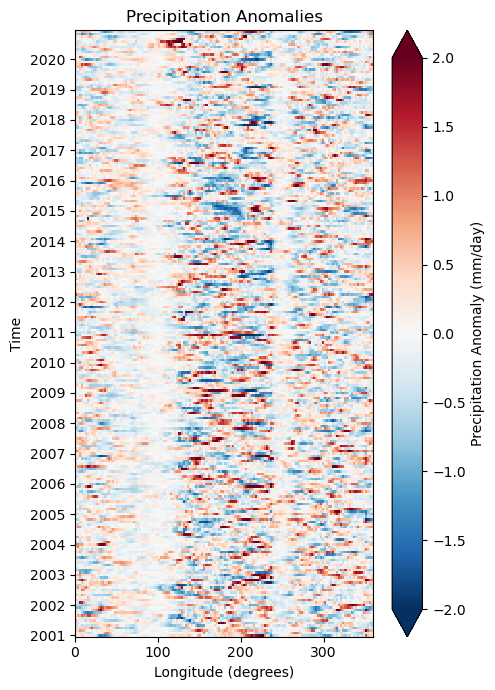

In [21]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(5,7))

# Create the Hovmöller plot
hov = precip_anomalies.plot(
    ax=ax, 
    x='lon', 
    y='time', 
    cmap='RdBu_r', 
    vmin=-2, vmax=2, extend='both',  # Adjust according to the anomaly magnitude
    cbar_kwargs={'label': 'Precipitation Anomaly (mm/day)'}
)

ax.set_title('Precipitation Anomalies')
ax.set_xlabel('Longitude (degrees)')
ax.set_ylabel('Time')

# Customize y-axis (time) format
ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_locator(mdates.YearLocator(1))

plt.tight_layout()
plt.show()


Interpretation of the Diagram:

- The horizontal axis represents longitude from west to east.
- The vertical axis represents time (years and months).
- Color shading indicates precipitation anomalies, highlighting wetter (blue) and drier (red) than average conditions.
- Diagonal or horizontal structures in the Hovmöller diagram indicate propagation or persistence of weather systems (e.g., storm systems, droughts).

This technique provides insights into the spatial–temporal dynamics of climate phenomena.